### 🛢️ Lithofacies Classification — FORCE 2020
##### 03 — EDA & Visualization

---

👤 **Author:** NMM | 📅 **Date:** 2026 | 📁 **Input:** `cleaned_data.csv`

**Pipeline:** `00 Combination` → `01 Exploration` → `02 Preprocessing` → **`03 EDA ◀`** → `04 Training` → `05 Evaluation`

---

##### 📌 Objectives
1. Load cleaned dataset
2. Visualize class distribution
3. Explore feature distributions per class
4. Plot feature correlations
5. Visualize well log patterns
6. Plot depth vs lithology per well
7. Analyze feature relationships
8. Export all figures for report

---

In [1]:
# Cell 1 - Imports & Load
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

sys.path.append("D:/Python/Lithofacies_Classification_NMM/src")
from config import *

# Style
plt.rcParams["figure.dpi"]      = 150
plt.rcParams["font.family"]     = "Segoe UI"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Load
df        = pd.read_csv(CLEANED_FILE, low_memory=False)
le_target = joblib.load(f"{MODEL_PATH}/le_target.pkl")

# Color palette per class
CLASS_COLORS = {
    "Shale"    : "#5B8DB8",
    "Sandstone": "#E8C87A",
    "Limestone": "#7DC8A0",
    "Anhydrite": "#E87A7A",
    "Marl"     : "#B8A0D8",
    "Igneous"  : "#E8A07A",
    "Coal"     : "#4A4A4A",
    "Tuff"     : "#A0C8B8"
}

print(f"✅ Data loaded!")
print(f"   Shape   : {df.shape}")
print(f"   Classes : {df['LITHO_FINAL'].unique()}")

✅ Config loaded!
✅ Data loaded!
   Shape   : (100793, 15)
   Classes : ['Shale' 'Limestone' 'Sandstone' 'Igneous' 'Marl' 'Tuff' 'Coal'
 'Anhydrite']


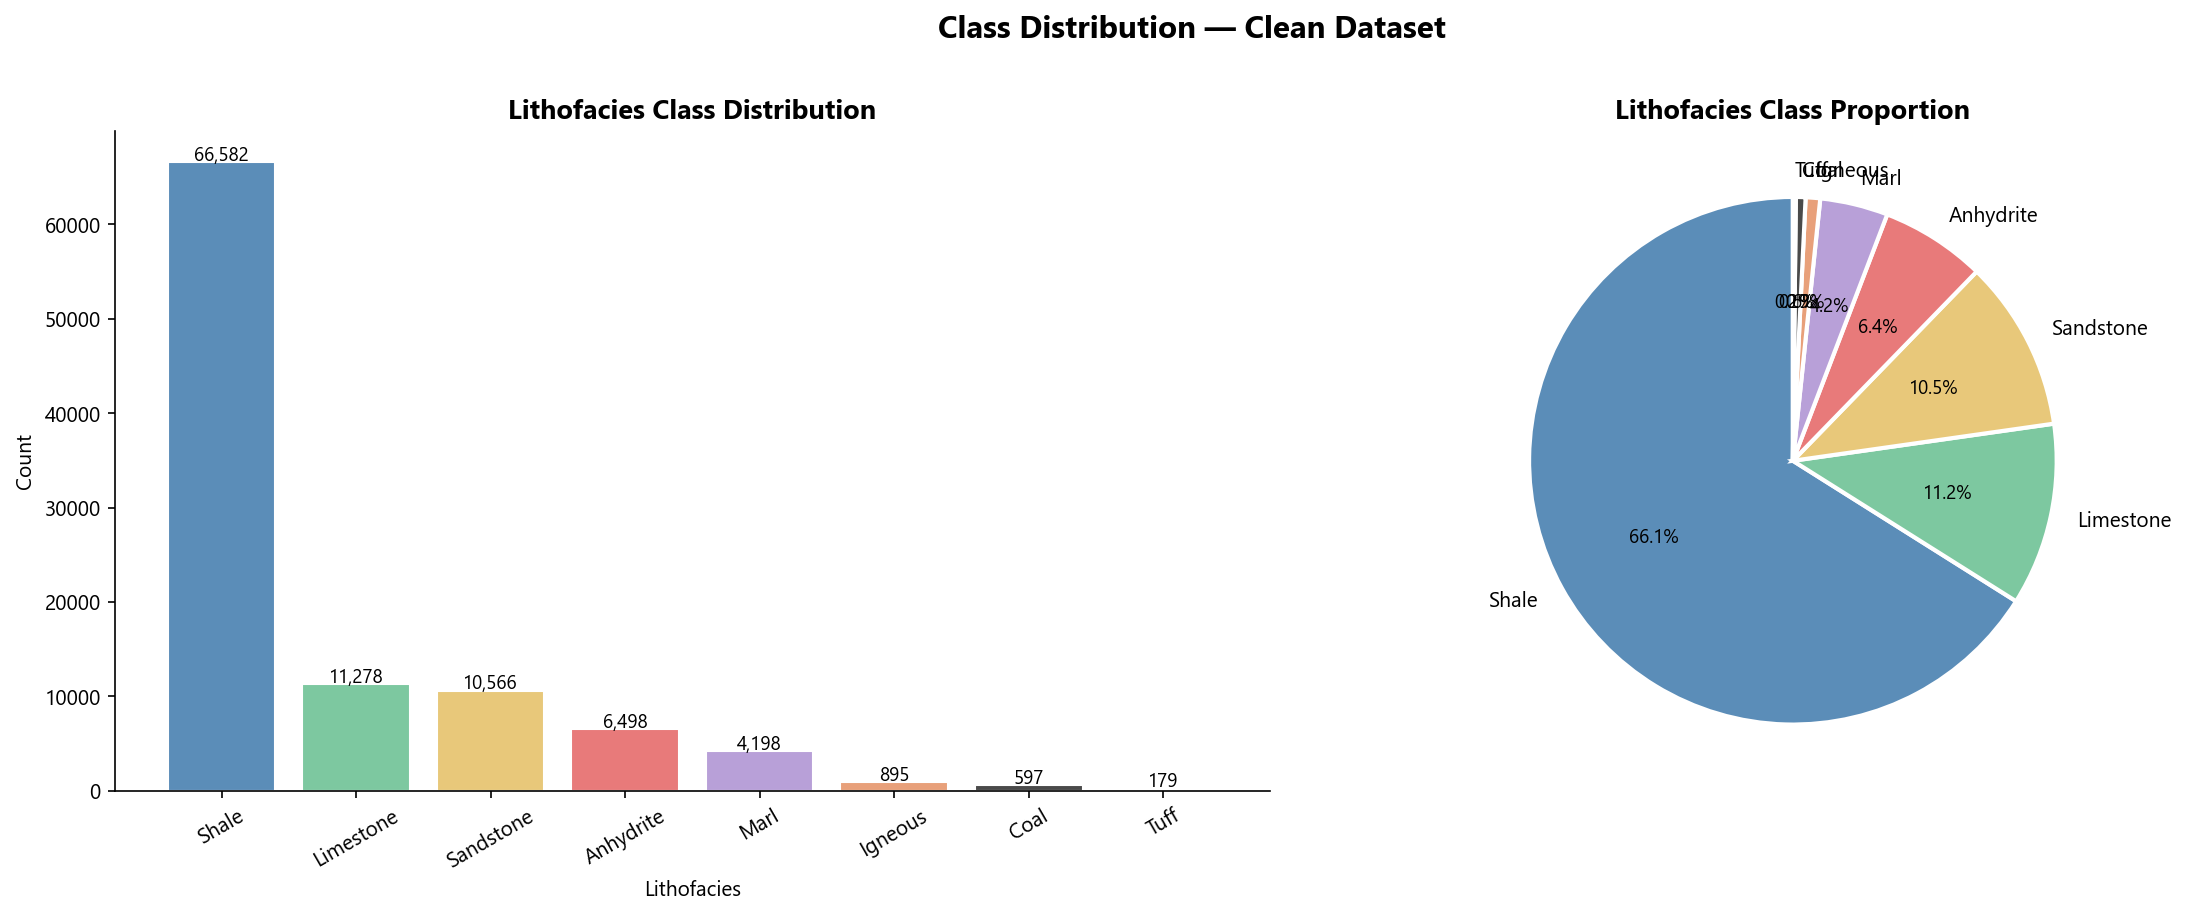

💾 Saved → eda_class_distribution.png


In [2]:
# Cell 2 - Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts  = df["LITHO_FINAL"].value_counts()
colors  = [CLASS_COLORS[c] for c in counts.index]
total   = len(df)

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white")
axes[0].set_title("Lithofacies Class Distribution", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Lithofacies")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f"{val:,}", ha="center", fontsize=9)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels    = counts.index,
    colors    = colors,
    autopct   = "%1.1f%%",
    startangle= 90,
    wedgeprops= dict(edgecolor="white", linewidth=2)
)
for text in autotexts:
    text.set_fontsize(9)
axes[1].set_title("Lithofacies Class Proportion", fontweight="bold", fontsize=13)

plt.suptitle("Class Distribution — Clean Dataset",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/eda_class_distribution.png", dpi=150)
plt.show()
print("💾 Saved → eda_class_distribution.png")

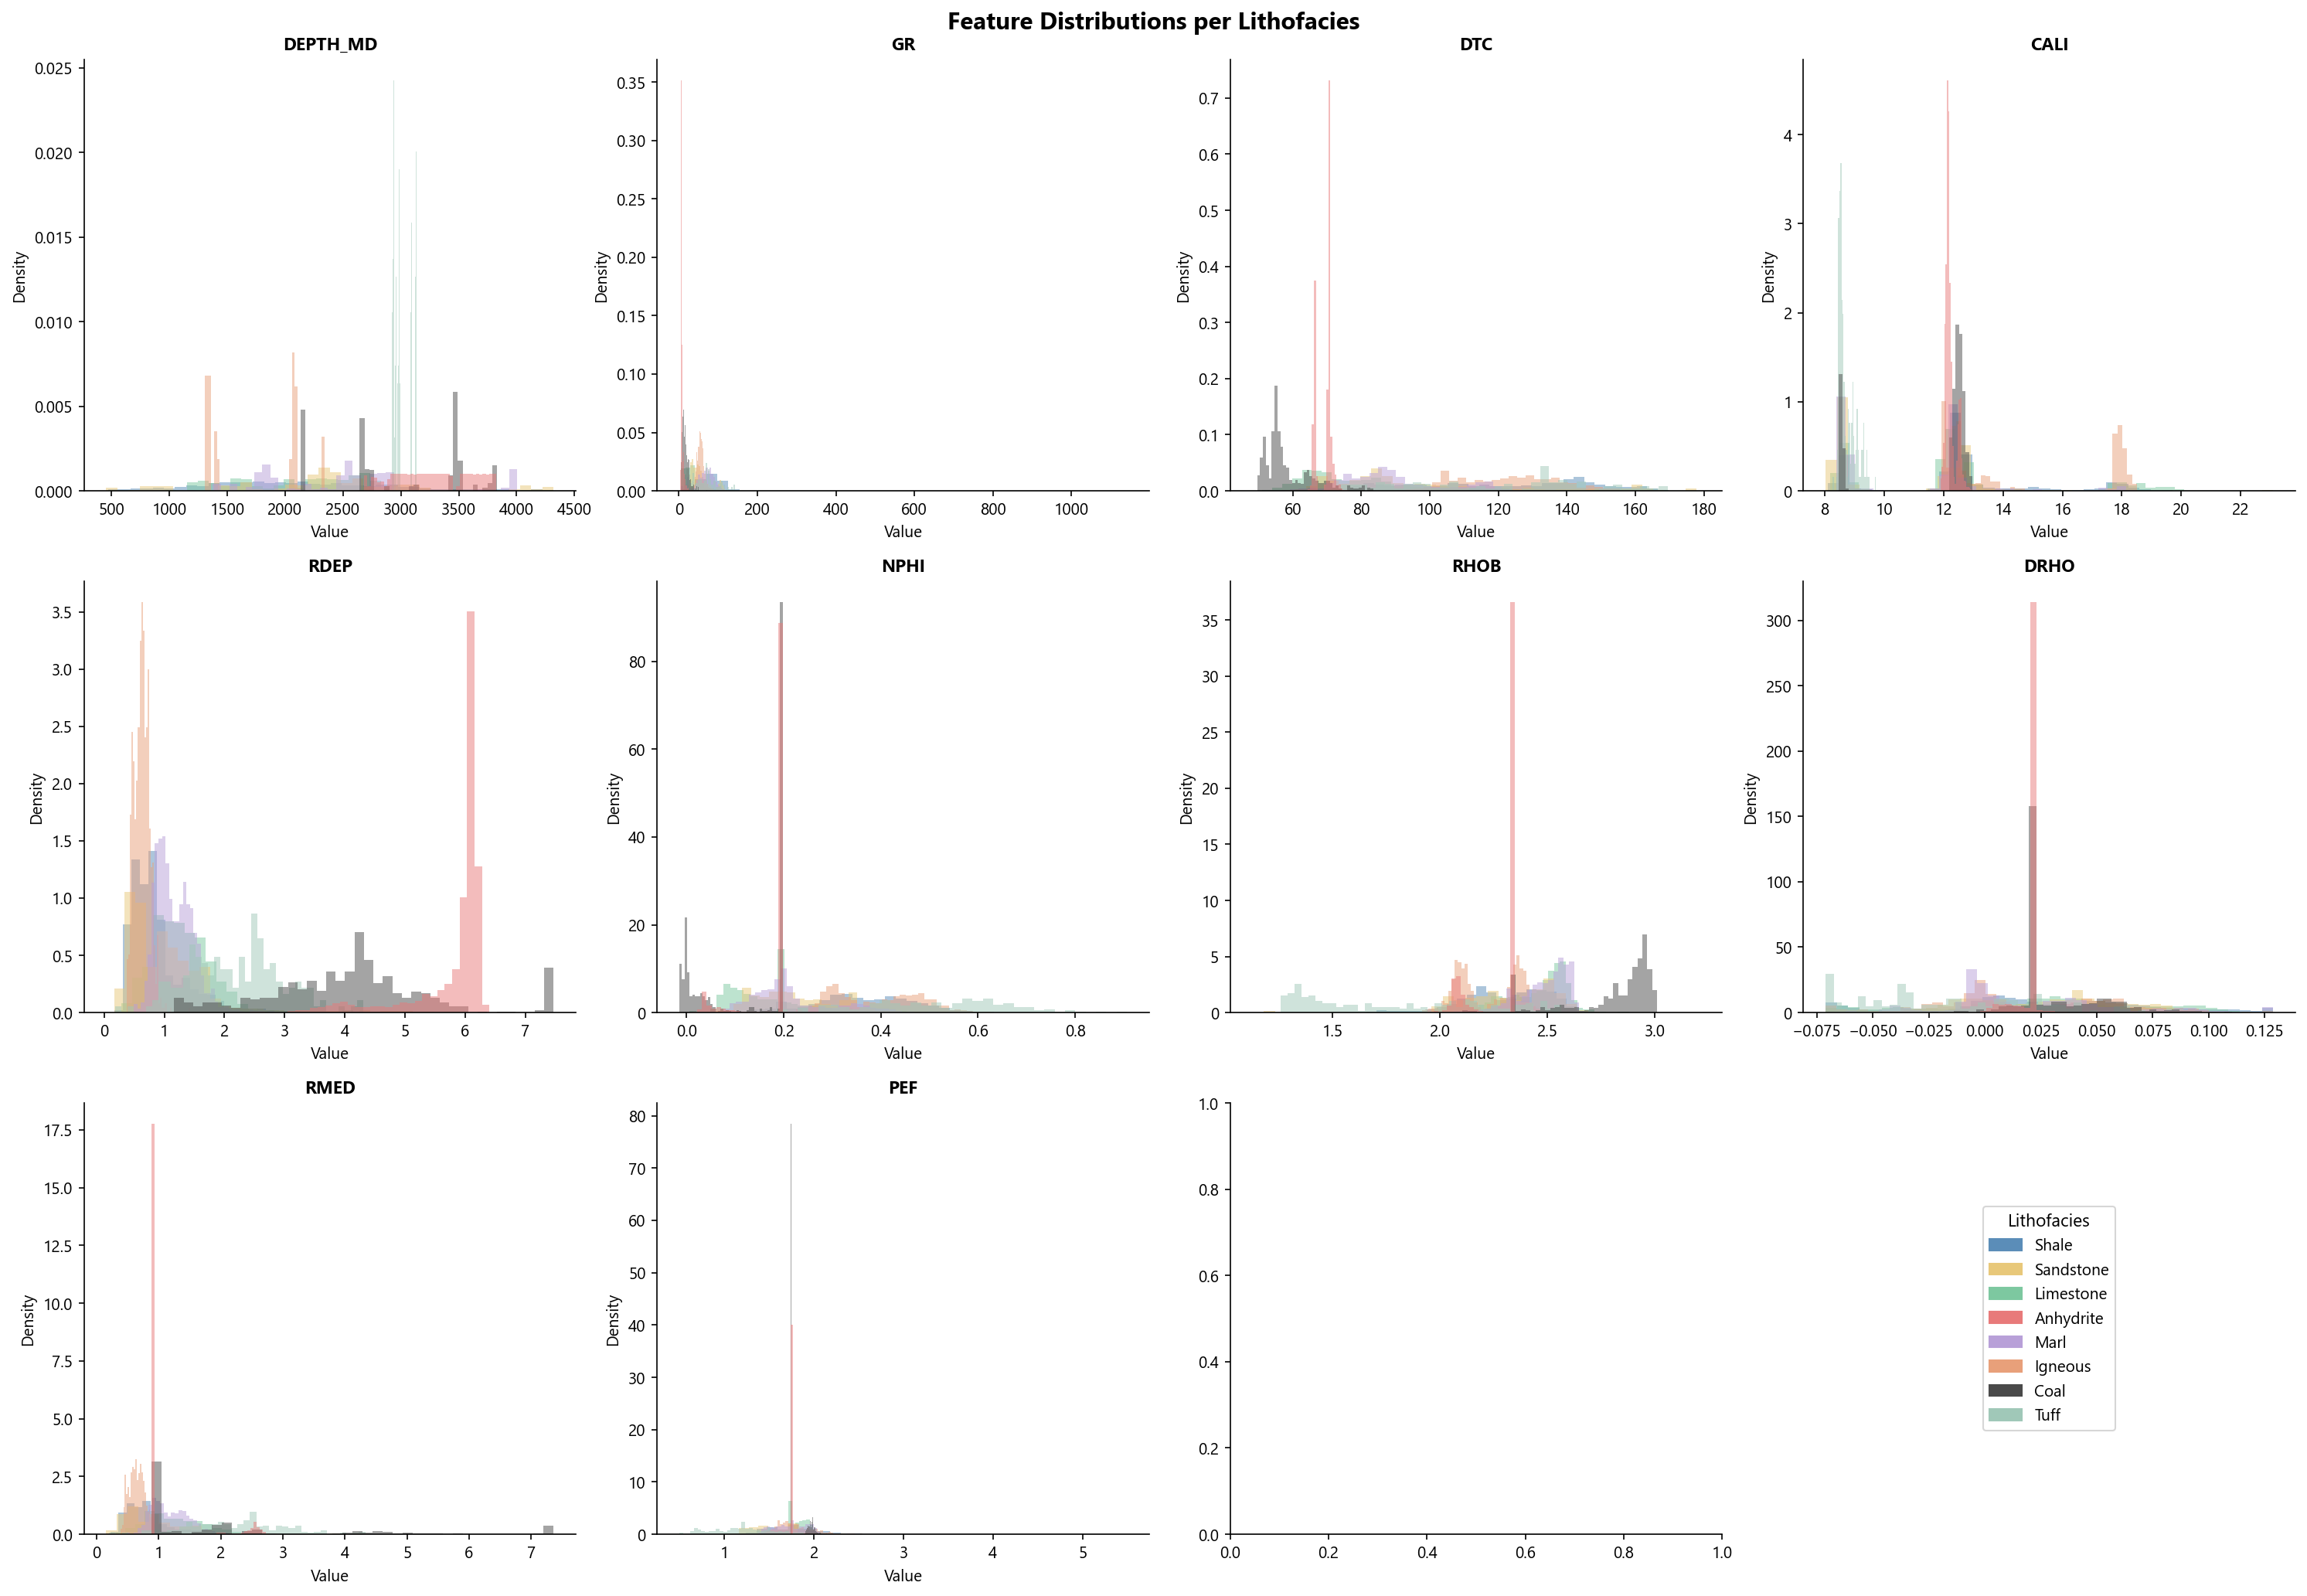

💾 Saved → eda_feature_distributions.png


In [3]:
# Cell 3 - Feature Distributions per Class
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(NUMERICAL_FEATURES):
    for cls in df["LITHO_FINAL"].unique():
        data = df[df["LITHO_FINAL"] == cls][feat].dropna()
        axes[i].hist(data, bins=40, alpha=0.5,
                     label=cls, color=CLASS_COLORS[cls],
                     edgecolor="none", density=True)
    axes[i].set_title(feat, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

# Legend on last subplot
axes[-1].axis("off")
handles = [plt.Rectangle((0,0),1,1, color=CLASS_COLORS[c])
           for c in CLASS_COLORS]
axes[-1].legend(handles, CLASS_COLORS.keys(),
                title="Lithofacies", fontsize=10,
                title_fontsize=11, loc="center")

plt.suptitle("Feature Distributions per Lithofacies",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/eda_feature_distributions.png", dpi=150)
plt.show()
print("💾 Saved → eda_feature_distributions.png")

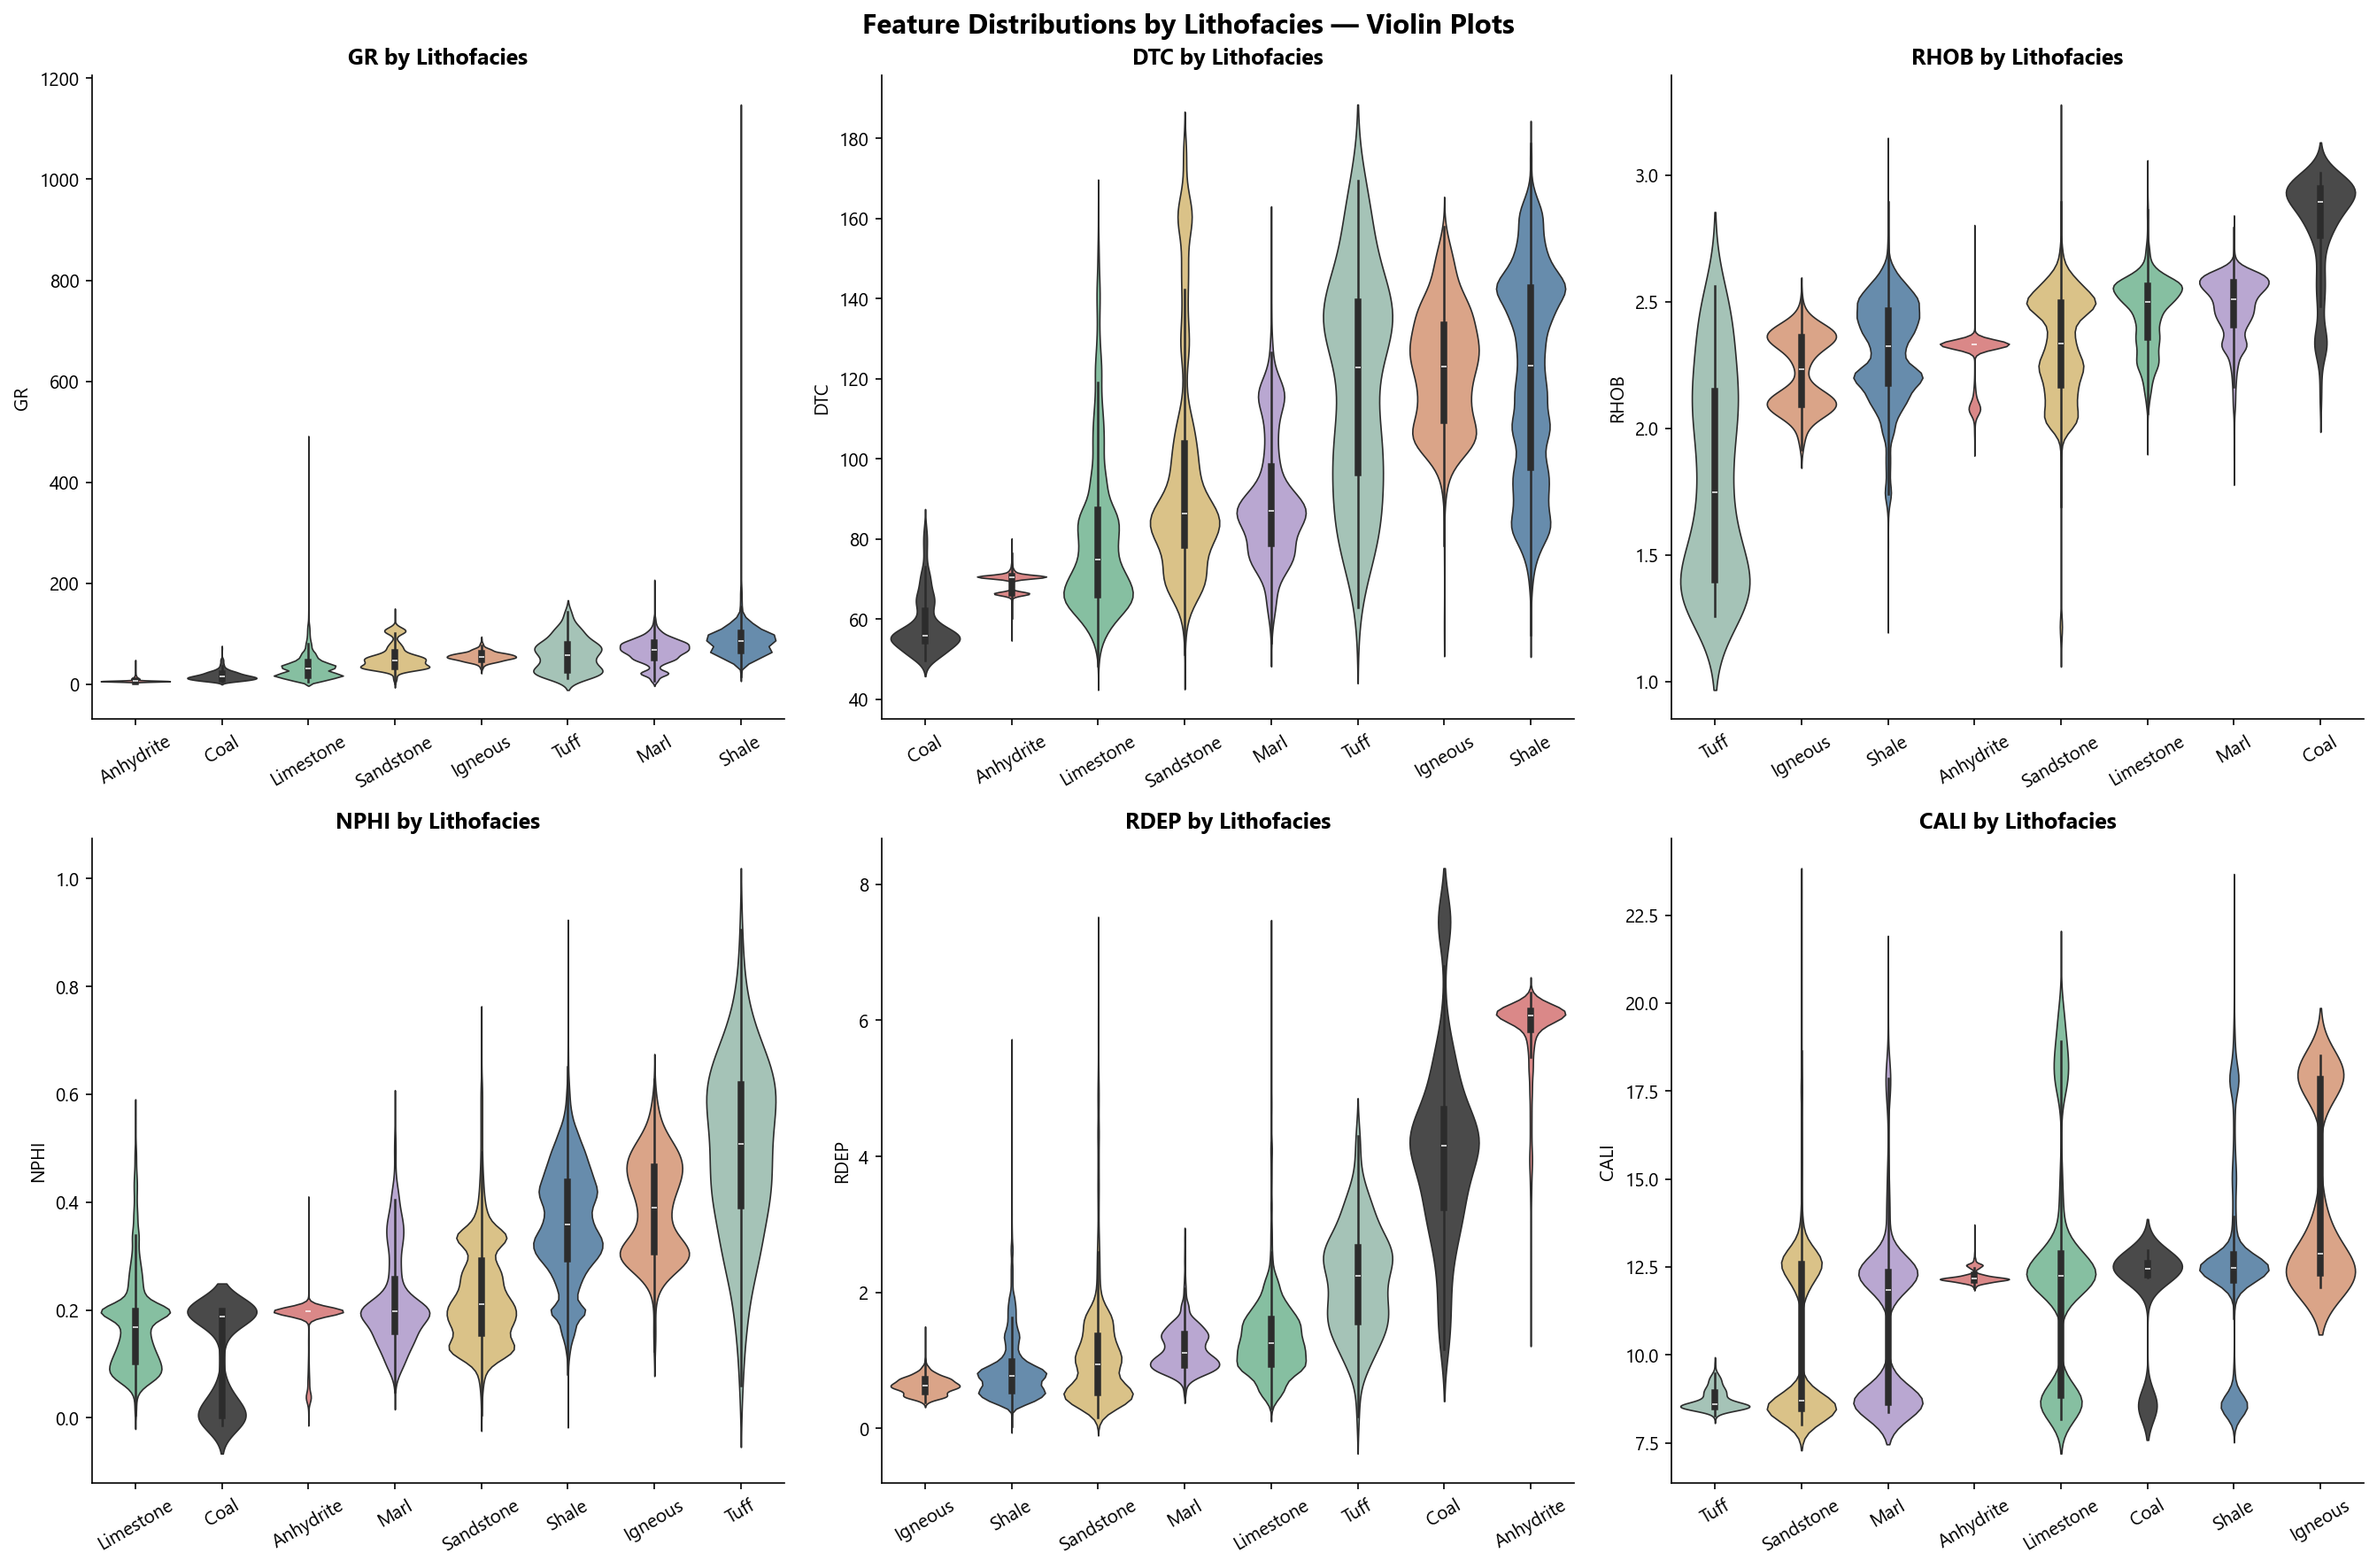

💾 Saved → eda_violin_plots.png


In [4]:
# Cell 4 - Violin Plots
top_features = ["GR", "DTC", "RHOB", "NPHI", "RDEP", "CALI"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data  = df[[feat, "LITHO_FINAL"]].dropna()
    order = data.groupby("LITHO_FINAL")[feat]\
                .median().sort_values().index

    sns.violinplot(
        data    = data,
        x       = "LITHO_FINAL",
        y       = feat,
        order   = order,
        palette = CLASS_COLORS,
        ax      = axes[i],
        inner   = "box",
        linewidth = 0.8
    )
    axes[i].set_title(f"{feat} by Lithofacies",
                      fontweight="bold", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Feature Distributions by Lithofacies — Violin Plots",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/eda_violin_plots.png", dpi=150)
plt.show()
print("💾 Saved → eda_violin_plots.png")

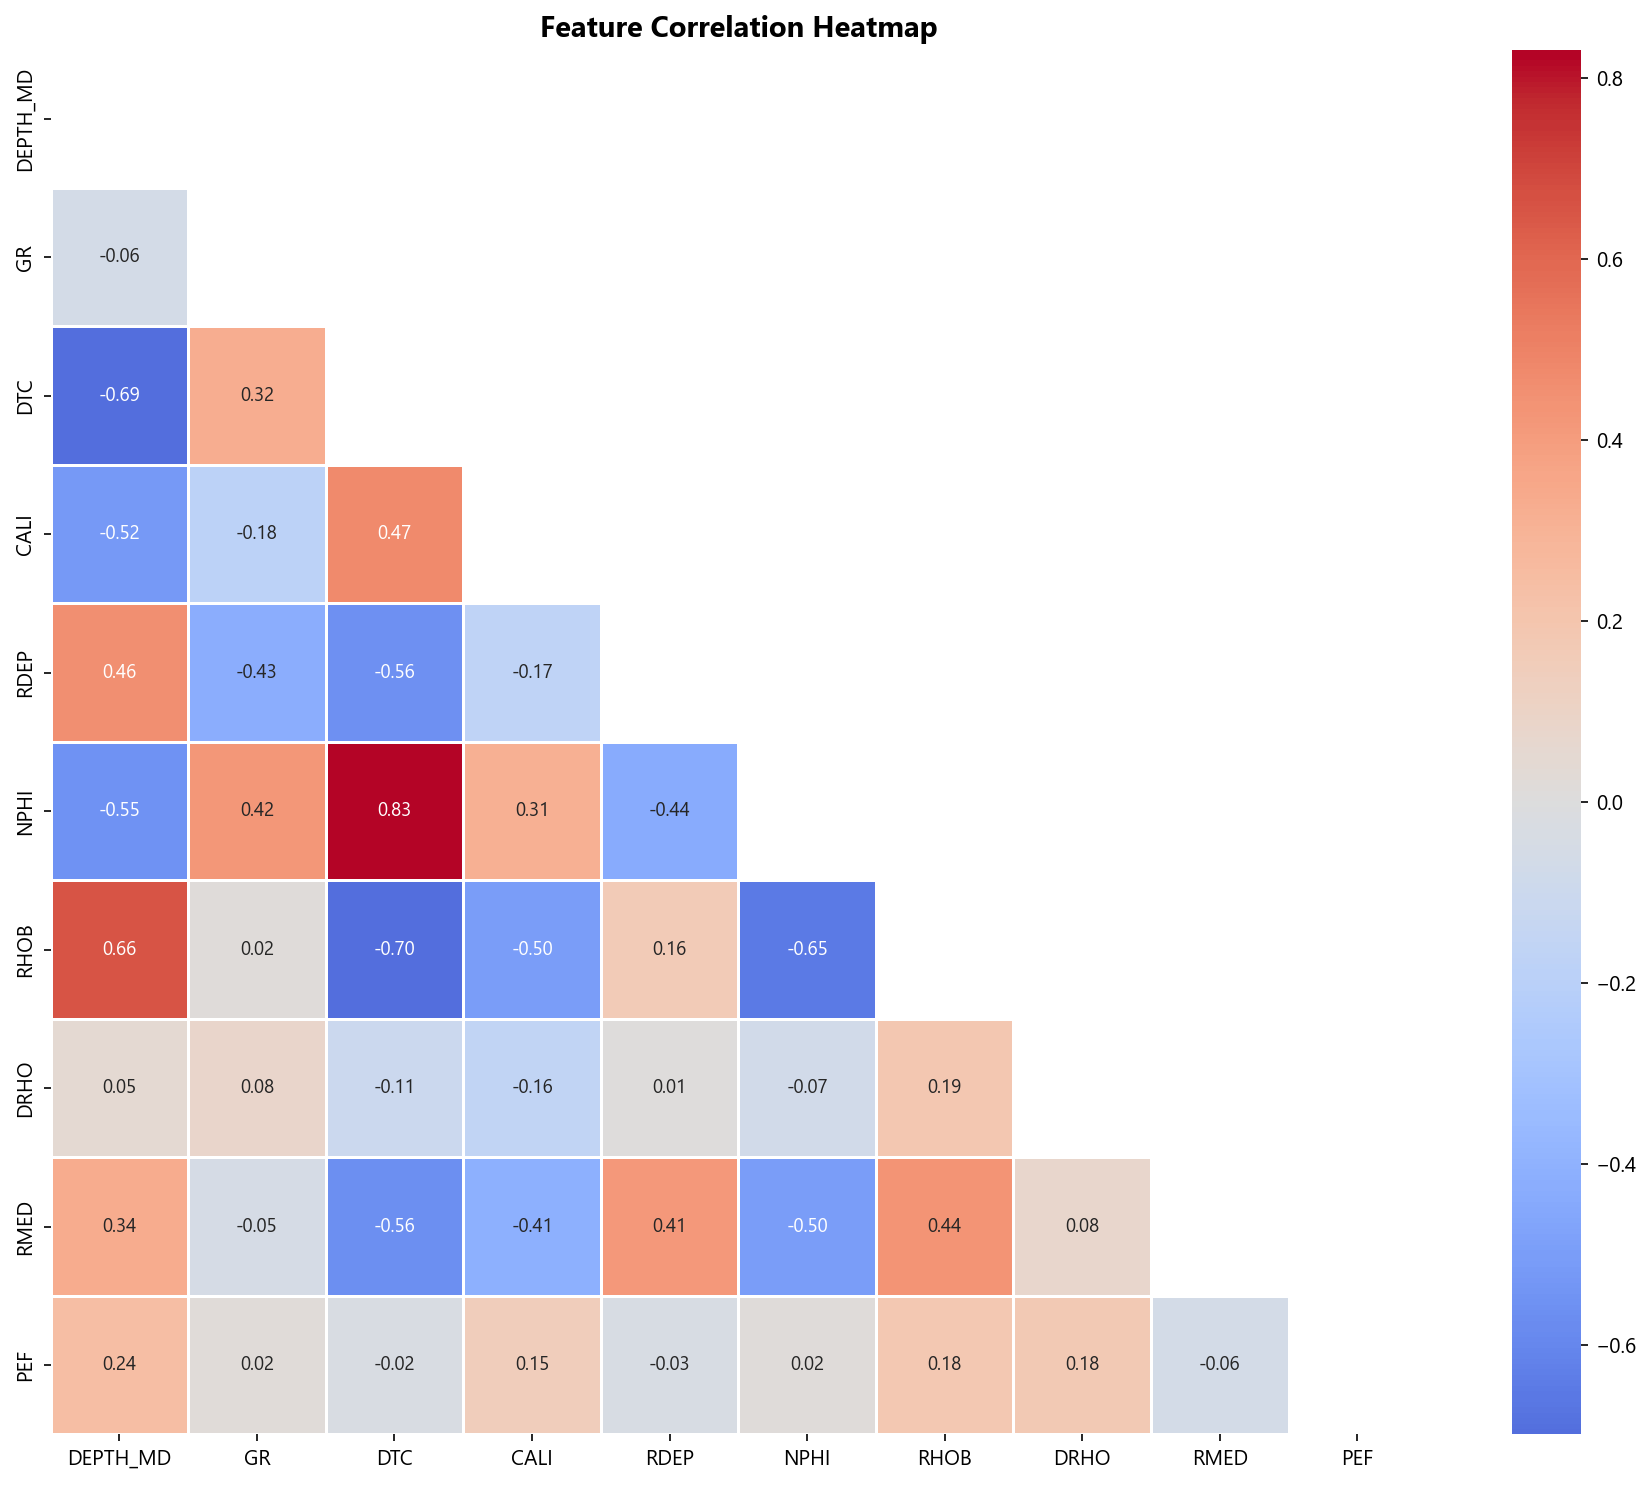

💾 Saved → eda_correlation_heatmap.png


In [5]:
# Cell 5 - Correlation Heatmap
corr = df[NUMERICAL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask    = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask      = mask,
    annot     = True,
    fmt       = ".2f",
    cmap      = "coolwarm",
    center    = 0,
    linewidths= 0.5,
    annot_kws = {"size": 9},
    ax        = ax
)

ax.set_title("Feature Correlation Heatmap",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/eda_correlation_heatmap.png", dpi=150)
plt.show()
print("💾 Saved → eda_correlation_heatmap.png")

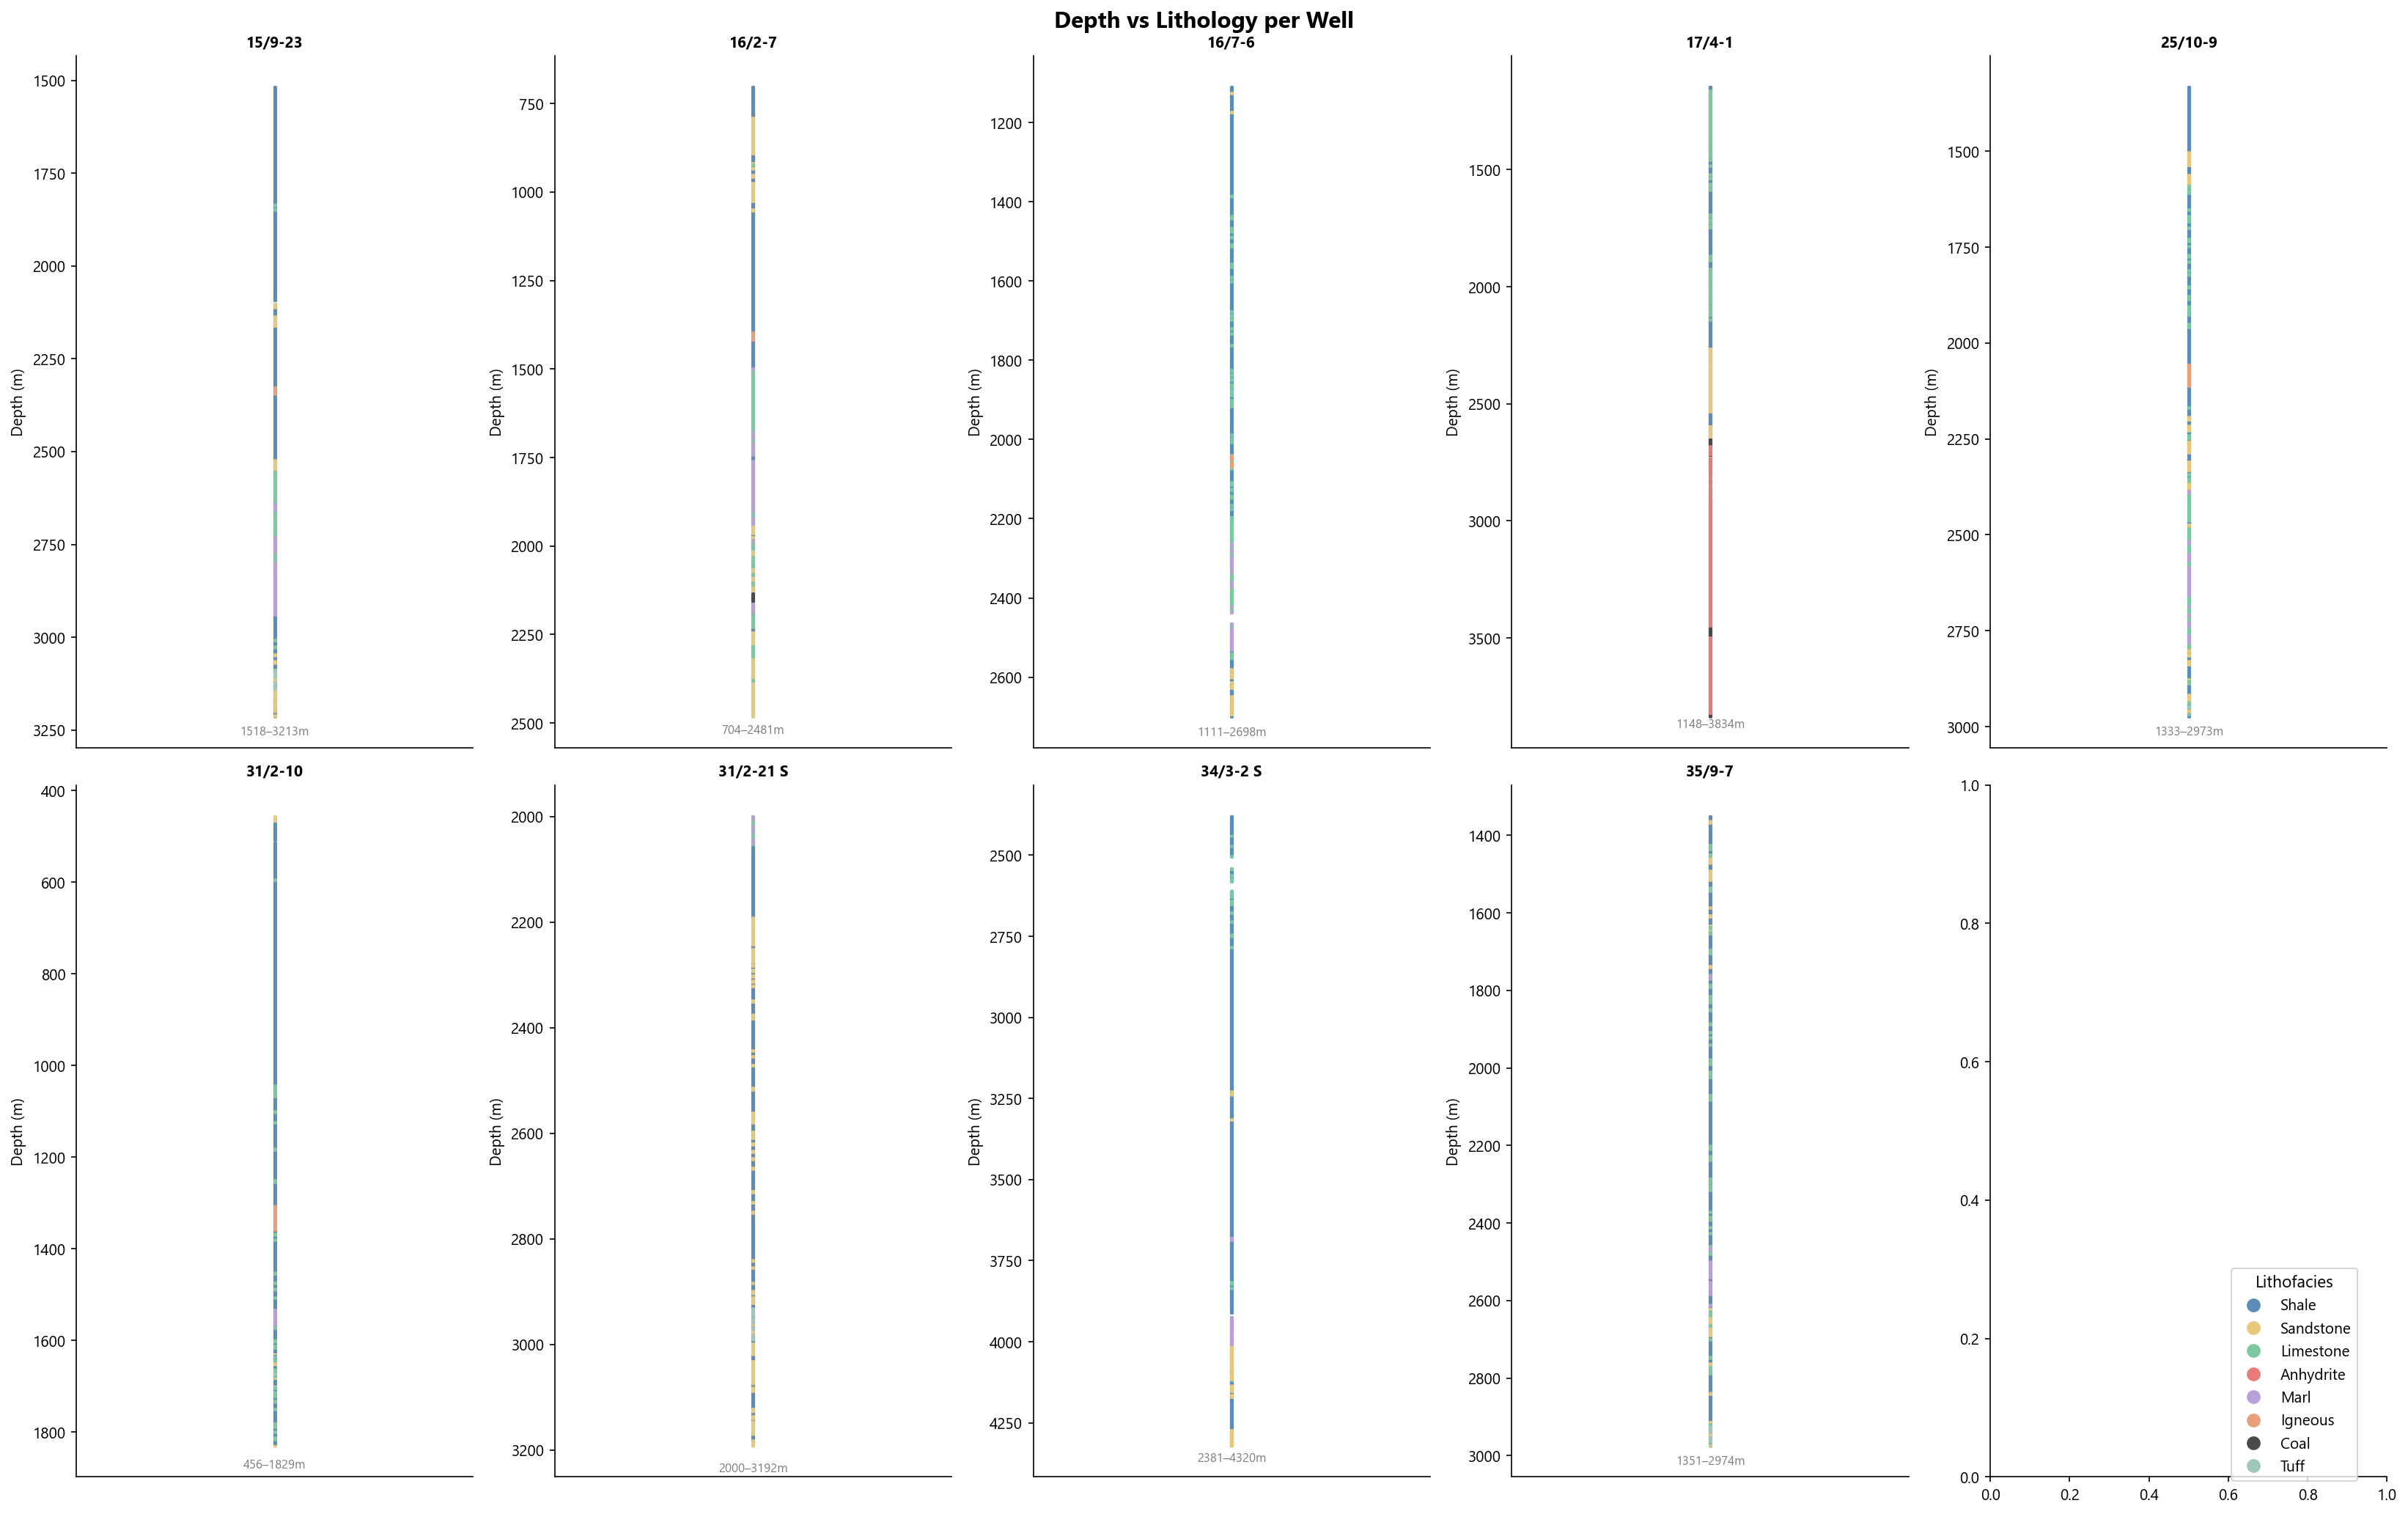

💾 Saved → eda_depth_lithology.png


In [6]:
# Cell 6 - Depth vs Lithology per Well
le_well  = joblib.load(f"{MODEL_PATH}/encoders.pkl")["WELL"]
wells    = df["WELL"].unique()
n_wells  = len(wells)

fig, axes = plt.subplots(2, 5, figsize=(22, 14))
axes = axes.flatten()

for i, well_enc in enumerate(sorted(wells)):
    well_df  = df[df["WELL"] == well_enc].sort_values("DEPTH_MD")
    well_name = le_well.inverse_transform([well_enc])[0]

    # Plot each lithology segment
    for cls in well_df["LITHO_FINAL"].unique():
        cls_df = well_df[well_df["LITHO_FINAL"] == cls]
        axes[i].scatter(
            [0.5] * len(cls_df),
            cls_df["DEPTH_MD"],
            c     = CLASS_COLORS.get(cls, "gray"),
            s     = 2,
            alpha = 0.6,
            label = cls
        )

    axes[i].set_title(well_name, fontweight="bold", fontsize=10)
    axes[i].set_ylabel("Depth (m)")
    axes[i].invert_yaxis()
    axes[i].set_xticks([])
    axes[i].set_xlim(0, 1)

    # Add depth range
    axes[i].text(0.5, well_df["DEPTH_MD"].max() + 50,
                 f"{well_df['DEPTH_MD'].min():.0f}–"
                 f"{well_df['DEPTH_MD'].max():.0f}m",
                 ha="center", fontsize=8, color="gray")

# Shared legend
handles = [plt.Line2D([0], [0], marker="o", color="w",
           markerfacecolor=CLASS_COLORS[c], markersize=10)
           for c in CLASS_COLORS]
fig.legend(handles, CLASS_COLORS.keys(),
           title="Lithofacies", loc="lower right",
           fontsize=10, title_fontsize=11,
           bbox_to_anchor=(0.98, 0.02))

plt.suptitle("Depth vs Lithology per Well",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/eda_depth_lithology.png", dpi=150)
plt.show()
print("💾 Saved → eda_depth_lithology.png")

Low GR  + Low DTC  → Coal ⚫ tight cluster
Low GR  + Low DTC  → Anhydrite 🔴 very tight!
Low GR  + High DTC → Tuff 🟦
High GR + High DTC → Shale 🔵 spreads wide
Mixed              → Sandstone/Limestone overlap

High RHOB + Low NPHI  → Coal ⚫ bottom right
Low  RHOB + Low NPHI  → Anhydrite 🔴 unique cluster!
Low  RHOB + High NPHI → Tuff 🟦 top left
Middle zone           → Shale/Sandstone/Limestone overlap

Low GR  + High RHOB → Coal ⚫ very distinct!
Low GR  + Low RHOB  → Anhydrite 🔴 unique!
High GR + Mid RHOB  → Shale 🔵 dominant cloud

Anhydrite → always isolated ✅ easy to classify
Coal      → always isolated ✅ easy to classify
Shale     → large overlapping cloud ⚠️
Sandstone → overlaps with Shale ⚠️
→ Confirms why Shale/Sandstone is our
  hardest classification boundary!

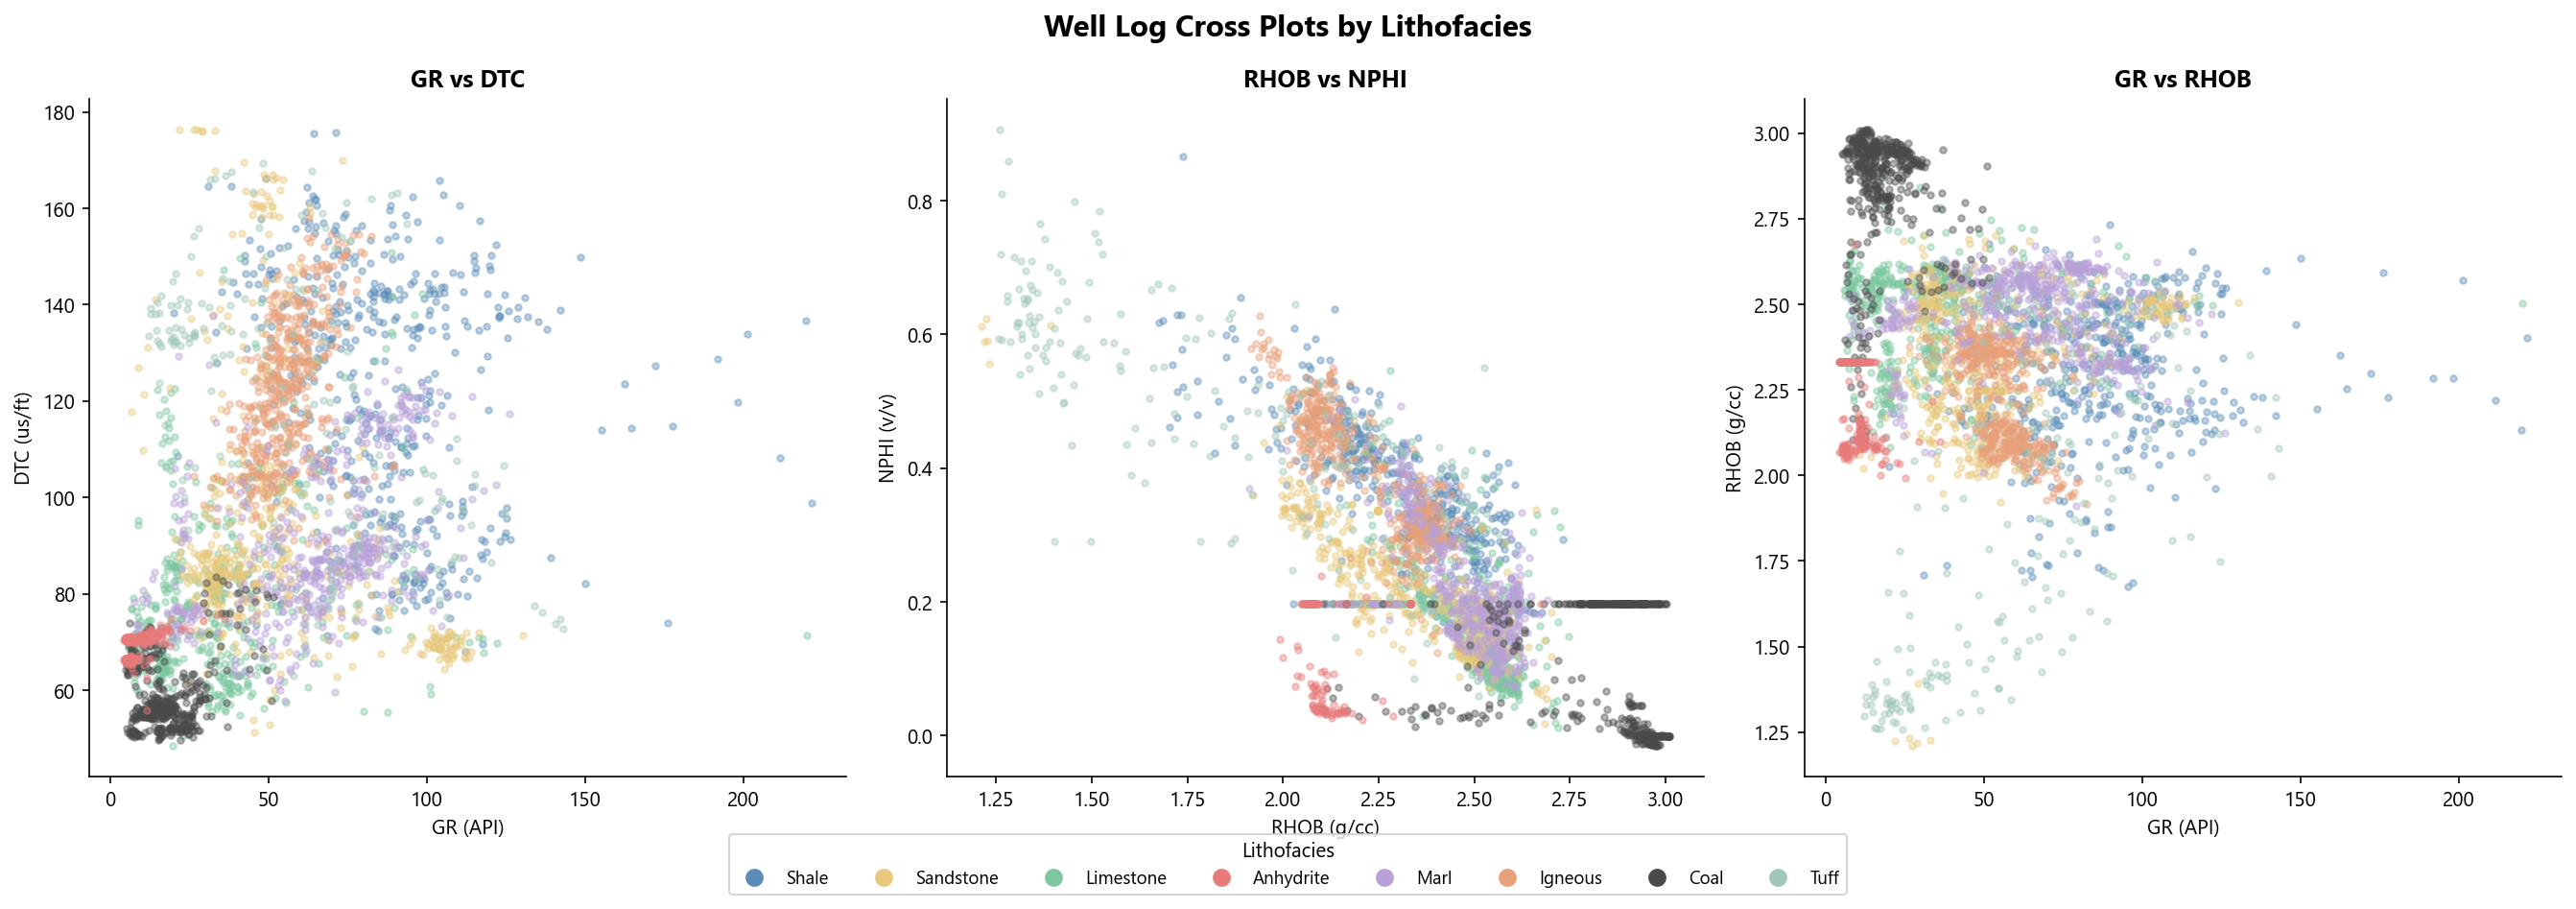

💾 Saved → eda_crossplots.png


In [7]:
# Cell 7 - Well Log Cross Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# GR vs DTC
for cls in df["LITHO_FINAL"].unique():
    data = df[df["LITHO_FINAL"] == cls].sample(
           min(500, len(df[df["LITHO_FINAL"] == cls])),
           random_state=42)
    axes[0].scatter(data["GR"], data["DTC"],
                    c=CLASS_COLORS[cls], alpha=0.4,
                    s=10, label=cls)
axes[0].set_xlabel("GR (API)")
axes[0].set_ylabel("DTC (us/ft)")
axes[0].set_title("GR vs DTC", fontweight="bold")

# RHOB vs NPHI
for cls in df["LITHO_FINAL"].unique():
    data = df[df["LITHO_FINAL"] == cls].sample(
           min(500, len(df[df["LITHO_FINAL"] == cls])),
           random_state=42)
    axes[1].scatter(data["RHOB"], data["NPHI"],
                    c=CLASS_COLORS[cls], alpha=0.4,
                    s=10, label=cls)
axes[1].set_xlabel("RHOB (g/cc)")
axes[1].set_ylabel("NPHI (v/v)")
axes[1].set_title("RHOB vs NPHI", fontweight="bold")

# GR vs RHOB
for cls in df["LITHO_FINAL"].unique():
    data = df[df["LITHO_FINAL"] == cls].sample(
           min(500, len(df[df["LITHO_FINAL"] == cls])),
           random_state=42)
    axes[2].scatter(data["GR"], data["RHOB"],
                    c=CLASS_COLORS[cls], alpha=0.4,
                    s=10, label=cls)
axes[2].set_xlabel("GR (API)")
axes[2].set_ylabel("RHOB (g/cc)")
axes[2].set_title("GR vs RHOB", fontweight="bold")

# Shared legend
handles = [plt.Line2D([0], [0], marker="o", color="w",
           markerfacecolor=CLASS_COLORS[c], markersize=10)
           for c in CLASS_COLORS]
fig.legend(handles, CLASS_COLORS.keys(),
           title="Lithofacies", loc="lower center",
           ncol=8, fontsize=9, title_fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Well Log Cross Plots by Lithofacies",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/eda_crossplots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → eda_crossplots.png")

RED   → above median importance → core features
BLUE  → below median importance → supporting features

TOP 6 (RED) — Core Features:
GR       48,654  → gamma ray = best lithology indicator
DEPTH_MD 45,756  → depth controls rock type
DTC      42,879  → sonic = rock hardness
CALI     40,938  → borehole size = rock stability
RHOB     39,045  → density = rock weight
DRHO     38,229  → density correction

BOTTOM 7 (BLUE) — Supporting:
RDEP, RMED, NPHI, PEF → resistivity & porosity
FORMATION, GROUP, WELL → geological context

Reading left to right = least to most important

WELL + GROUP + FORMATION → only 7% combined
Add PEF + NPHI + RMED    → reach 39%
Add RDEP + DRHO + RHOB   → reach 67%
Add CALI + DTC           → reach 86%
Add DEPTH_MD + GR        → reach 100% ✅

Key thresholds:
→ Need 12 features to reach 90% ✅
→ Need 13 features to reach 95% ✅

GR + DEPTH_MD + DTC = top 3
→ These 3 alone make ~30% of decisions
→ Classic well log interpretation!
   Geologists have used GR + DTC
   for decades — ML agrees! ✅

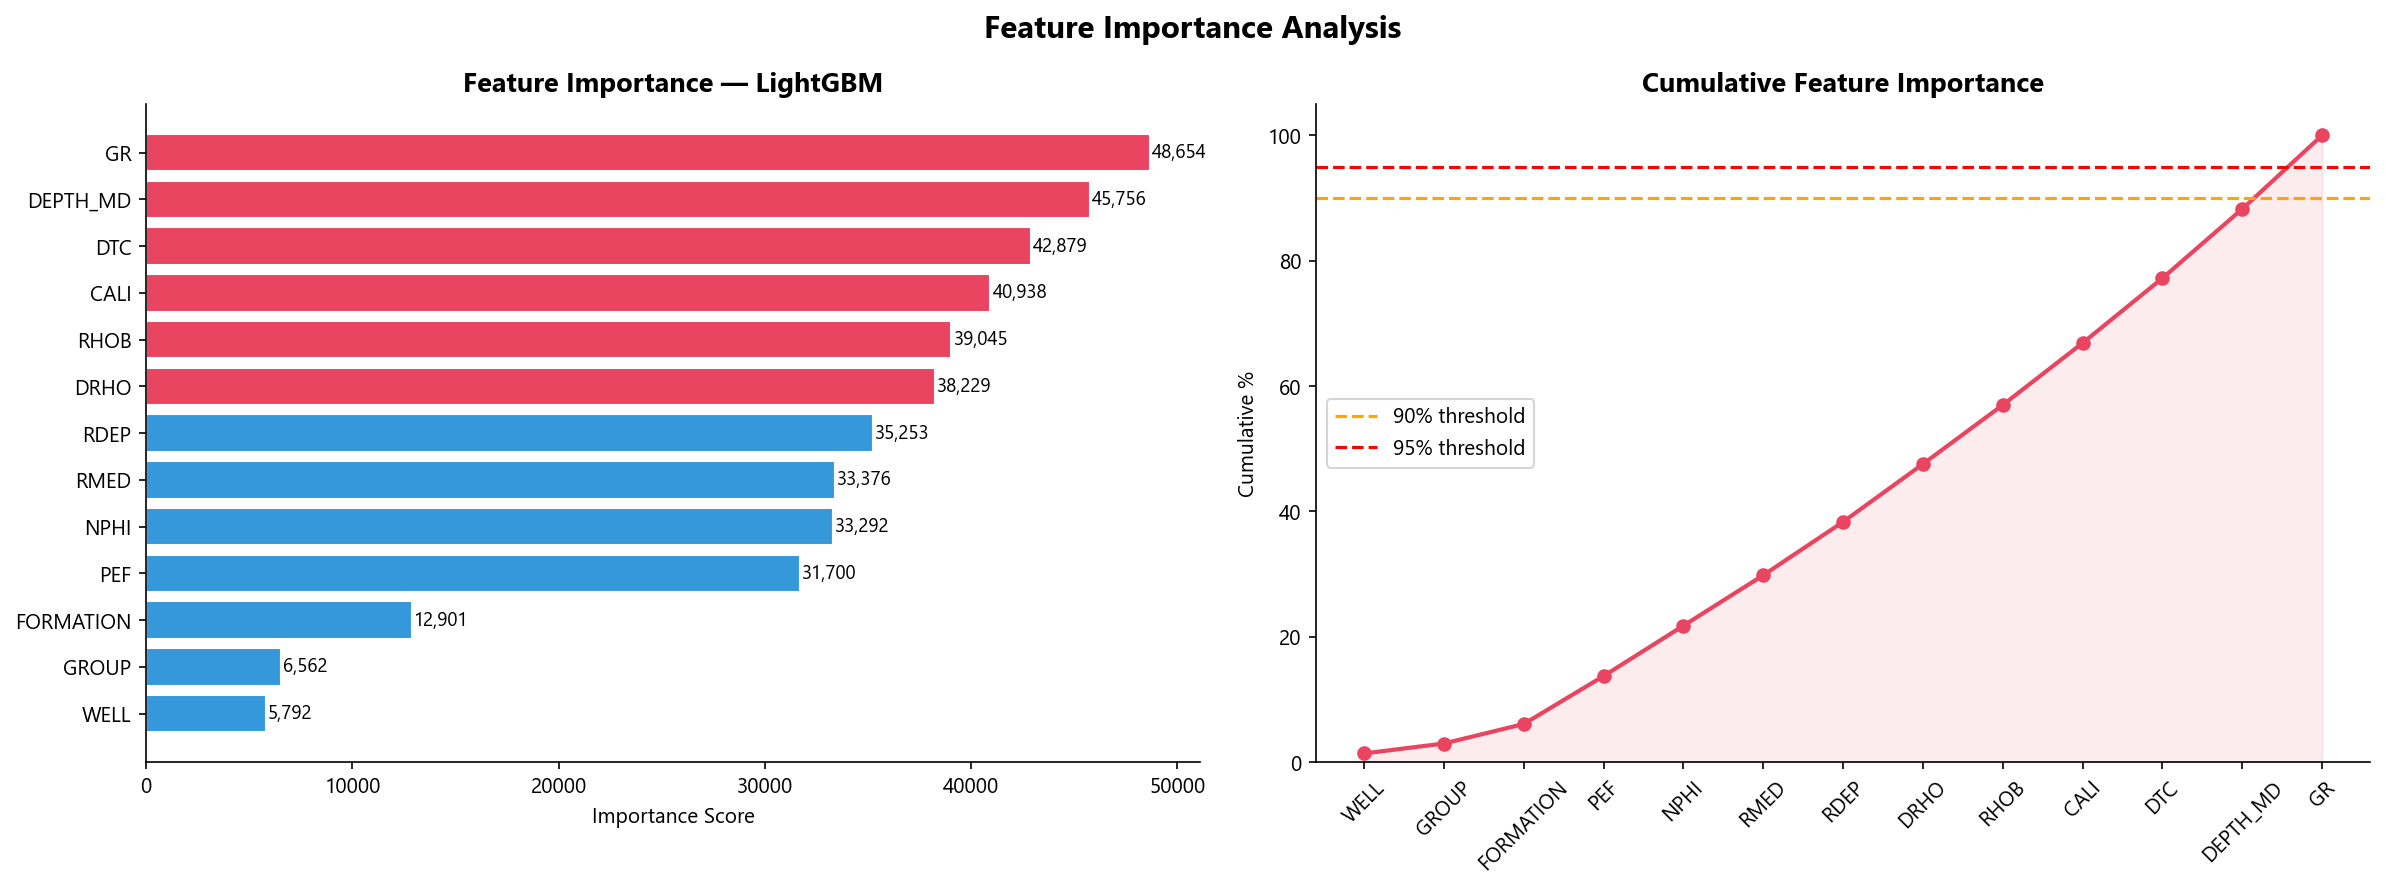

💾 Saved → eda_feature_importance.png


In [9]:
# Cell 8 - Feature Importance Final Plot
model = joblib.load(f"{MODEL_PATH}/best_model.pkl")

importance_df = pd.DataFrame({
    "Feature"   : FEATURES_13,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

importance_df["Cumulative"] = importance_df["Importance"]\
    .cumsum() / importance_df["Importance"].sum() * 100

colors = ["#e94560" if imp > importance_df["Importance"].median()
          else "#3498db" for imp in importance_df["Importance"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar
axes[0].barh(importance_df["Feature"],
             importance_df["Importance"],
             color=colors, edgecolor="white")
axes[0].set_title("Feature Importance — LightGBM",
                  fontweight="bold", fontsize=13)
axes[0].set_xlabel("Importance Score")
for i, (val, feat) in enumerate(zip(
        importance_df["Importance"],
        importance_df["Feature"])):
    axes[0].text(val + 100, i, f"{val:,}",
                 va="center", fontsize=9)

# Cumulative
axes[1].plot(importance_df["Feature"],
             importance_df["Cumulative"],
             marker="o", color="#e94560",
             linewidth=2, markersize=6)
axes[1].fill_between(importance_df["Feature"],
                     importance_df["Cumulative"],
                     alpha=0.1, color="#e94560")
axes[1].axhline(y=90, color="orange", linestyle="--",
                label="90% threshold")
axes[1].axhline(y=95, color="red", linestyle="--",
                label="95% threshold")
axes[1].set_title("Cumulative Feature Importance",
                  fontweight="bold", fontsize=13)
axes[1].set_ylabel("Cumulative %")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle("Feature Importance Analysis",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/eda_feature_importance.png", dpi=150)
plt.show()
print("💾 Saved → eda_feature_importance.png")

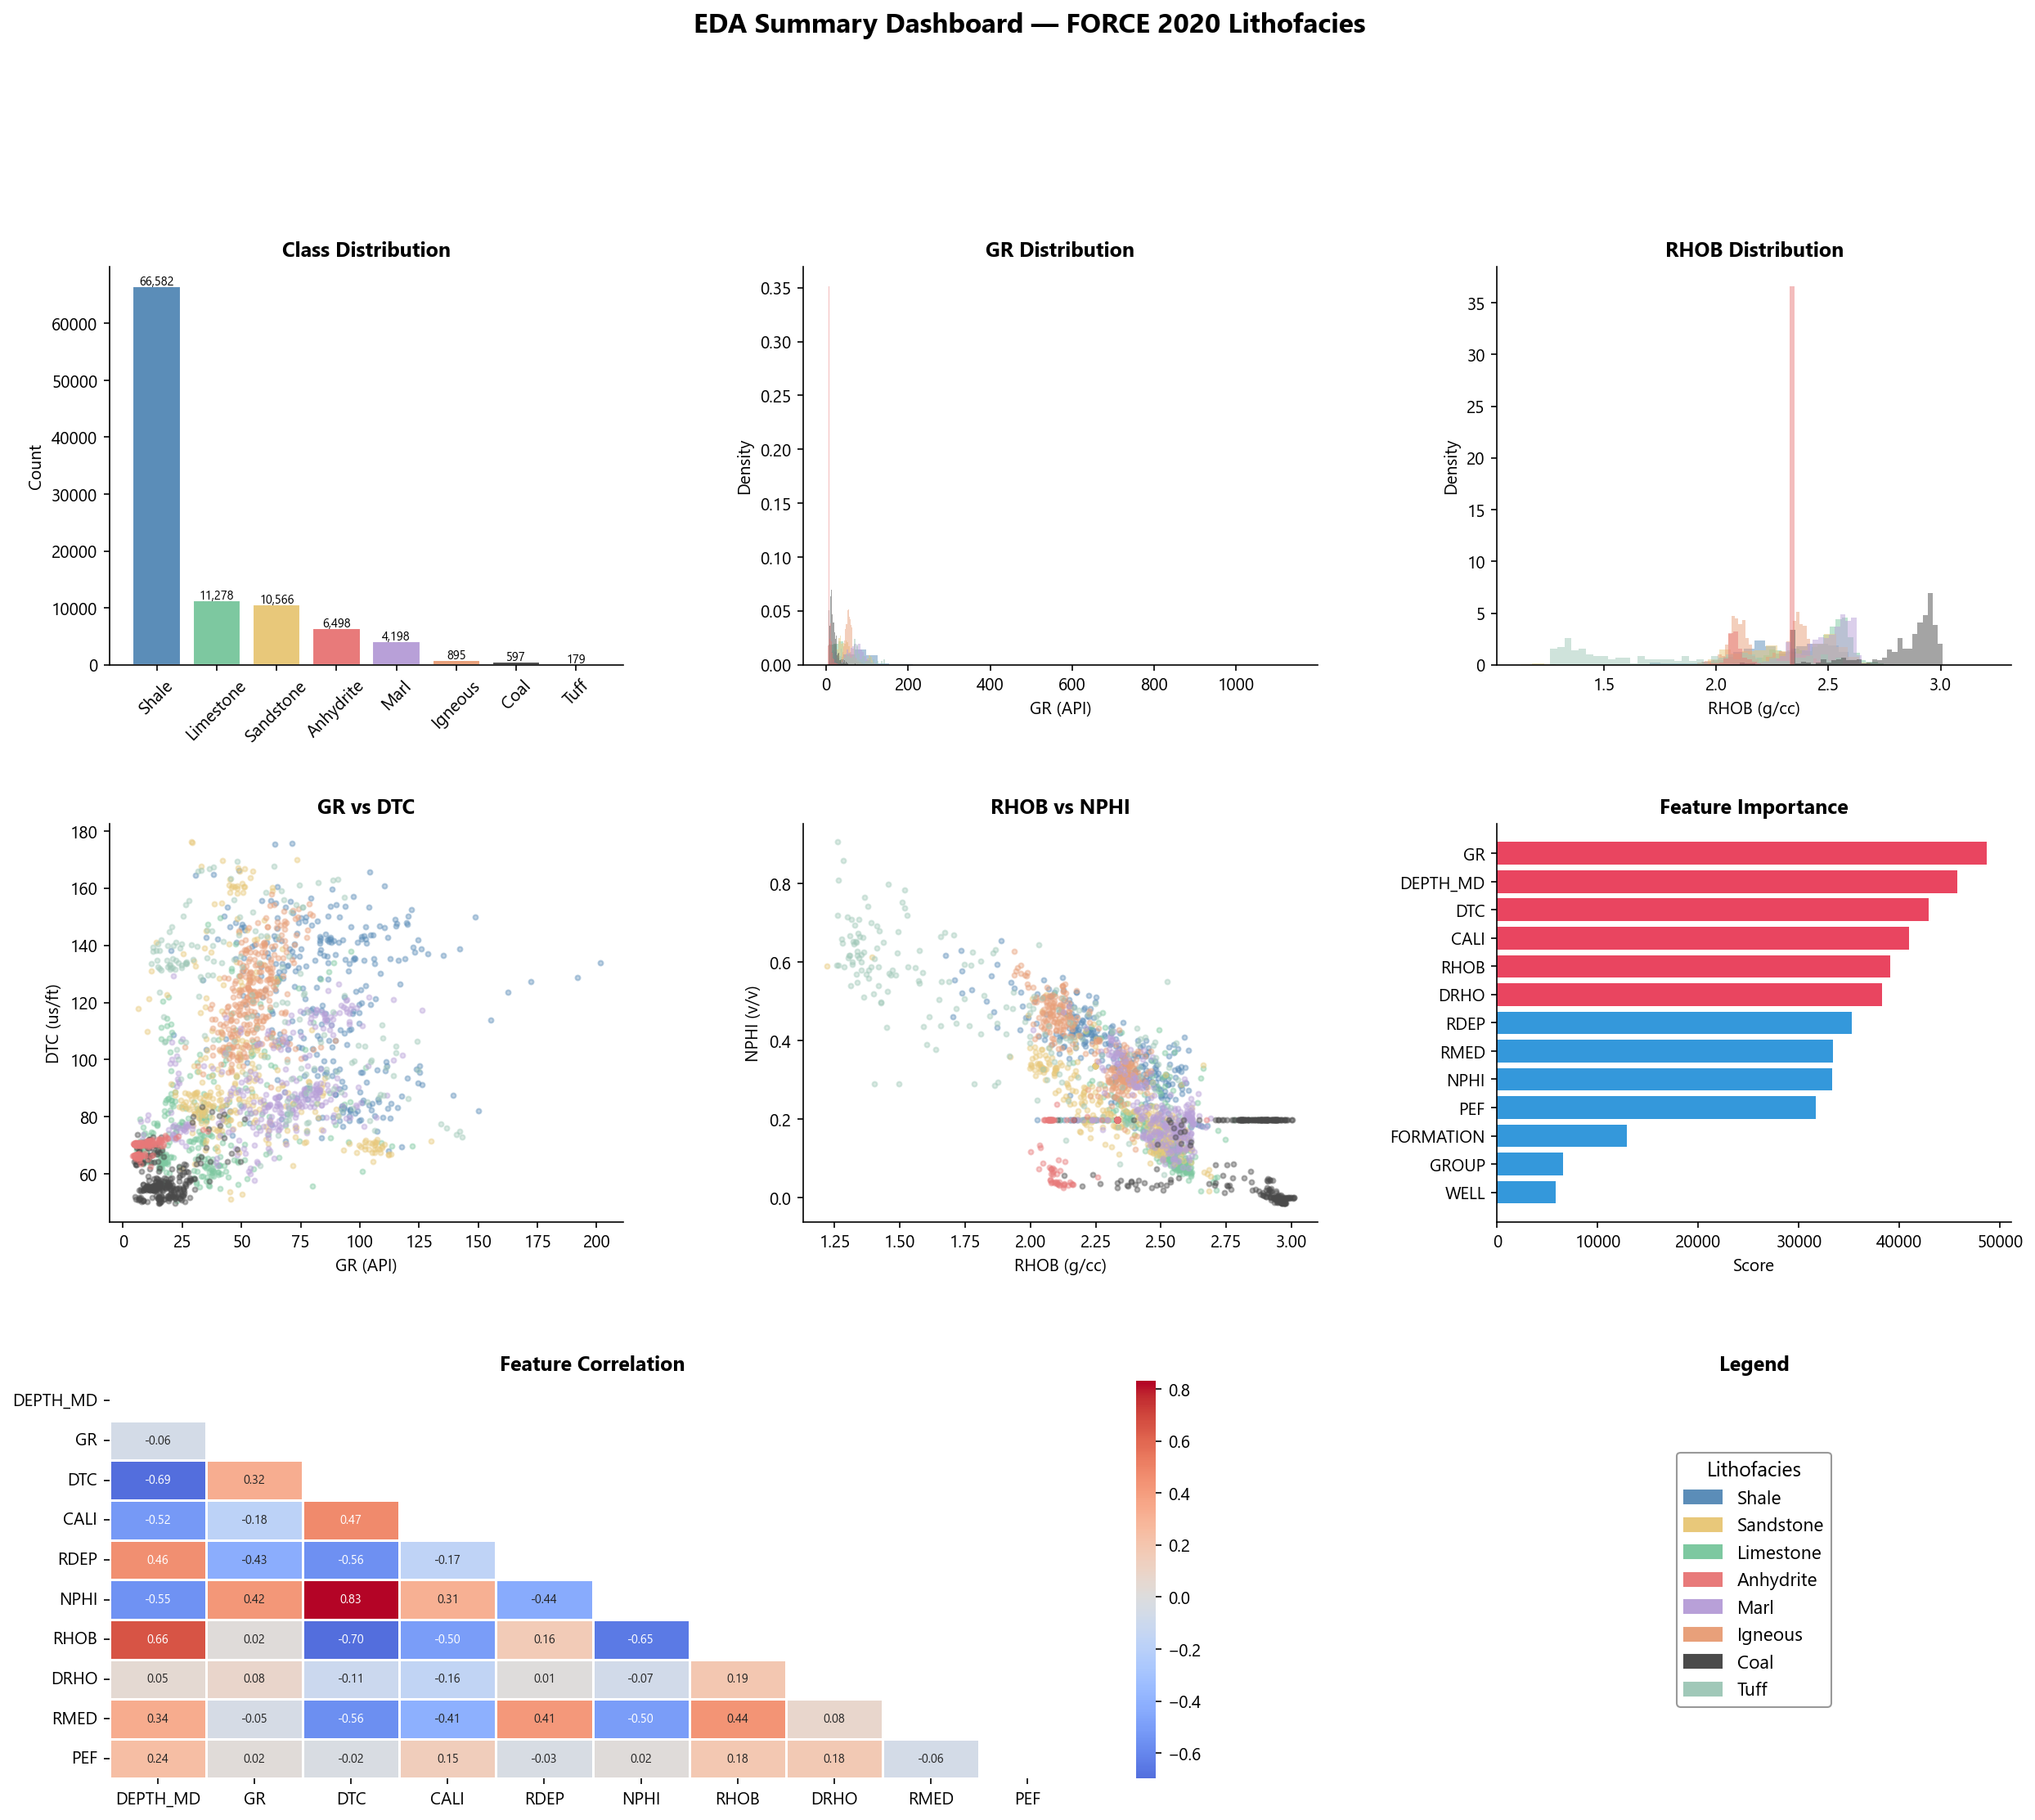

💾 Saved → eda_summary_dashboard.png

✅ 03_EDA_Visualization Complete!

Figures saved:
   eda_class_distribution.png
   eda_feature_distributions.png
   eda_violin_plots.png
   eda_correlation_heatmap.png
   eda_depth_lithology.png
   eda_crossplots.png
   eda_feature_importance.png
   eda_summary_dashboard.png



In [10]:
# Cell 9 - EDA Summary Dashboard
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Class Distribution ────────────────────────────────
ax1    = fig.add_subplot(gs[0, 0])
counts = df["LITHO_FINAL"].value_counts()
colors = [CLASS_COLORS[c] for c in counts.index]
bars   = ax1.bar(counts.index, counts.values,
                 color=colors, edgecolor="white")
ax1.set_title("Class Distribution", fontweight="bold")
ax1.tick_params(axis="x", rotation=45)
ax1.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f"{val:,}", ha="center", fontsize=7)

# ── 2. GR Distribution ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for cls in df["LITHO_FINAL"].unique():
    data = df[df["LITHO_FINAL"] == cls]["GR"].dropna()
    ax2.hist(data, bins=40, alpha=0.5, density=True,
             color=CLASS_COLORS[cls], label=cls)
ax2.set_title("GR Distribution", fontweight="bold")
ax2.set_xlabel("GR (API)")
ax2.set_ylabel("Density")

# ── 3. RHOB Distribution ─────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for cls in df["LITHO_FINAL"].unique():
    data = df[df["LITHO_FINAL"] == cls]["RHOB"].dropna()
    ax3.hist(data, bins=40, alpha=0.5, density=True,
             color=CLASS_COLORS[cls], label=cls)
ax3.set_title("RHOB Distribution", fontweight="bold")
ax3.set_xlabel("RHOB (g/cc)")
ax3.set_ylabel("Density")

# ── 4. GR vs DTC Crossplot ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for cls in df["LITHO_FINAL"].unique():
    data = df[df["LITHO_FINAL"] == cls].sample(
           min(300, len(df[df["LITHO_FINAL"] == cls])),
           random_state=42)
    ax4.scatter(data["GR"], data["DTC"],
                c=CLASS_COLORS[cls], alpha=0.4, s=8)
ax4.set_title("GR vs DTC", fontweight="bold")
ax4.set_xlabel("GR (API)")
ax4.set_ylabel("DTC (us/ft)")

# ── 5. RHOB vs NPHI Crossplot ────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for cls in df["LITHO_FINAL"].unique():
    data = df[df["LITHO_FINAL"] == cls].sample(
           min(300, len(df[df["LITHO_FINAL"] == cls])),
           random_state=42)
    ax5.scatter(data["RHOB"], data["NPHI"],
                c=CLASS_COLORS[cls], alpha=0.4, s=8)
ax5.set_title("RHOB vs NPHI", fontweight="bold")
ax5.set_xlabel("RHOB (g/cc)")
ax5.set_ylabel("NPHI (v/v)")

# ── 6. Feature Importance ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
imp_df = pd.DataFrame({
    "Feature"   : FEATURES_13,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)
colors_imp = ["#e94560" if v > imp_df["Importance"].median()
              else "#3498db" for v in imp_df["Importance"]]
ax6.barh(imp_df["Feature"], imp_df["Importance"],
         color=colors_imp)
ax6.set_title("Feature Importance", fontweight="bold")
ax6.set_xlabel("Score")

# ── 7. Correlation Heatmap ───────────────────────────────
ax7  = fig.add_subplot(gs[2, 0:2])
corr = df[NUMERICAL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 7}, ax=ax7)
ax7.set_title("Feature Correlation", fontweight="bold")

# ── 8. Legend ────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis("off")
handles = [plt.Rectangle((0,0), 1, 1,
           color=CLASS_COLORS[c]) for c in CLASS_COLORS]
ax8.legend(handles, CLASS_COLORS.keys(),
           title="Lithofacies", fontsize=11,
           title_fontsize=12, loc="center",
           frameon=True, edgecolor="gray")
ax8.set_title("Legend", fontweight="bold")

plt.suptitle(
    "EDA Summary Dashboard — FORCE 2020 Lithofacies",
    fontsize=16, fontweight="bold", y=1.01)

plt.savefig(f"{FIGURES_PATH}/eda_summary_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → eda_summary_dashboard.png")

print(f"""
✅ 03_EDA_Visualization Complete!

Figures saved:
   eda_class_distribution.png
   eda_feature_distributions.png
   eda_violin_plots.png
   eda_correlation_heatmap.png
   eda_depth_lithology.png
   eda_crossplots.png
   eda_feature_importance.png
   eda_summary_dashboard.png
""")